$Step-1$:

**Read the packages**

In [13]:
import numpy as np                                                                         # 79 thclass
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
!pip install warnings

ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)
ERROR: No matching distribution found for warnings


$step-2$:

**Read the data**

In [11]:
df=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [12]:
df.dropna(inplace=True)

In [19]:
print(df.shape)
print(df.columns)
df.info()

(1599, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   f

**Objective**:

    - Predict the quality of wine

- you can apply ML models no numerical data only
- In above data set target column is: Quality
- You need to predict the quality of the wine based input given columns
- The target column data type is categorical data, convert into numerical before apply ML model
- If you have any missing values, impute before apply ML model

**Process to apply ML model**

- First will divide data into 2 parts
- Train and test data with the ratio of 80:20 or 70:30
- X: input column, Y=output column
- Train data has both input anf output data: **X_train, y_train**
- Test data also ha both input and output data: **X_test, y_test**
- Will develop ML model using Train data, which means using **X_train, y_train**
- Will pass the X_test alone to the develop model
- Then the model will give some output values, these are called **y_predictions**
- Finally will compare y_test with y_predictions
- Then will calculate all the metrics

$Step-3$:

**In order to divide train and test data, first seperate input data and output data**

In [22]:
df.columns

# from df you need to create
# X: input data
# y: Output data

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [23]:
# Drop the quality column from  original data:   will get ""Input data""
# select the quality column from original data:  output data
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [24]:
# input data
X=df.drop('quality',axis=1)
# output
y=df['quality']

In [27]:
X.head()
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

$Step-4$:

**Split the data into train and test**

In [28]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=1234)


# we are passing X: input   y:output
# We are dividing the data 80:20
# test size=0.2 ===> 20% is test
# we divide data randomly random_state=1234
# Automatically 80% become train data

In [48]:
df.shape,X.shape,y.shape

((1599, 12), (1599, 11), (1599,))

In [47]:
# check-1: check the data sample count
# train data is 80%
1599*80/100   # 1280 samples are train data

# test data is 20%
1599*20/100   # 320 sample are test data

319.8

In [39]:
# check-2: check the shapes
print(df.shape)        # total 12 columns data: 1599

print(X_train.shape)          # (1279,11)
print(X_test.shape)           # (320,11)
print(y_train.shape)          # (1279,)
print(y_test.shape)           # (320,)

(1599, 12)
(1279, 11)
(320, 11)
(1279,)
(320,)


In [40]:
# check-3:

# Read the first 5 values of X_train and y_train
# And check the id : both should be same 
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
441,11.9,0.40,0.65,2.15,0.068,7.0,27.0,0.99880,3.06,0.68,11.3
227,9.0,0.82,0.14,2.60,0.089,9.0,23.0,0.99840,3.39,0.63,9.8
1386,7.4,0.64,0.07,1.80,0.100,8.0,23.0,0.99610,3.30,0.58,9.6
1245,7.4,0.55,0.19,1.80,0.082,15.0,34.0,0.99655,3.49,0.68,10.5
60,8.8,0.40,0.40,2.20,0.079,19.0,52.0,0.99800,3.44,0.64,9.2


In [41]:
y_train[:5]

441     6
227     5
1386    5
1245    5
60      5
Name: quality, dtype: int64

In [43]:
####################### All together ########################
# Step-1
df=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')

# Step-2

# input data
X=df.drop('quality',axis=1)
# output
y=df['quality']


# Step-3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=1234)

# Step-4
print(X_train.shape)          # (1279,11)
print(X_test.shape)           # (320,11)
print(y_train.shape)          # (1279,)
print(y_test.shape)

(1279, 11)
(320, 11)
(1279,)
(320,)


$Step-5$:

**Develop the ML model**
- Read the package
- save the package
- apply fit

In [45]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
LR

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


$Step-6$:

**Get the Model Predictions**

will passs X_test to get the predictions

In [52]:
y_predictions=LR.predict(X_test)     # X_test=320

# y_predictions are given by model
len(y_predictions)

320

In [95]:
# y_test consider as actual output                                                # 80 class
len(y_test)

320

In [57]:
y_test[:5].values,y_predictions[:5]     # here u can see output ""test array & prediction array""  are similar

(array([5, 5, 6, 6, 7]),
 array([5.18402693, 5.35222632, 5.59491103, 5.52091961, 6.34175415]))

$Step-7$:

**Metrics**: Evaluation

In [ ]:
# LabelEncoder : Preprocessing technique
# StandardScalar : Preprocessing technique
# from sklearn.preprocessing import LabelEncoder

# train test split: model related
# from sklearn.model_selection import train_test_split

# Linear regression:
# from sklearn.<linear_model> import LinearRegression

# from sklearn.<tree> import DT

In [59]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [60]:
# we need to pass actual output y_test, predictions y_predictionsmean

print(mean_squared_error(y_test,y_predictions))
print(mean_absolute_error(y_test,y_predictions))
print(r2_score(y_test,y_predictions))

0.3798884734410354
0.47036477238747665
0.3675833642704228


In [61]:
print(mean_squared_error(y_test[:5],y_predictions[:5]))

0.19696639718199987


In [75]:
# doing """mean square error manually""" print(mean_squared_error(y_test,y_predictions))
# understand the formulae
# summ(y_test-y_predctions)^2

# will take each observation: for loop
# will do subtraction
# will do the square
# summation
# summation/n
import numpy as np  
summ=0
for i in range(len(y_test)):
    # print((y_test.values[i]-y_predictions[i])**2)                     # here to do square we need numpy package
    summ=summ+(y_test.values[i]-y_predictions[i])**2

summ/len(y_test)

np.float64(0.37988847344103527)

In [82]:
mse=mean_squared_error(y_test,y_predictions)
mae=mean_absolute_error(y_test,y_predictions)
R2_score=r2_score(y_test,y_predictions)

# Find RMSE by using mse
RMSE=np.sqrt(mse)

print("mean square error:",mse)
print("root mean square error:",RMSE)
print("R2:",R2_score)

mean square error: 0.3798884734410354
root mean square error: 0.6163509336741816
R2: 0.3675833642704228


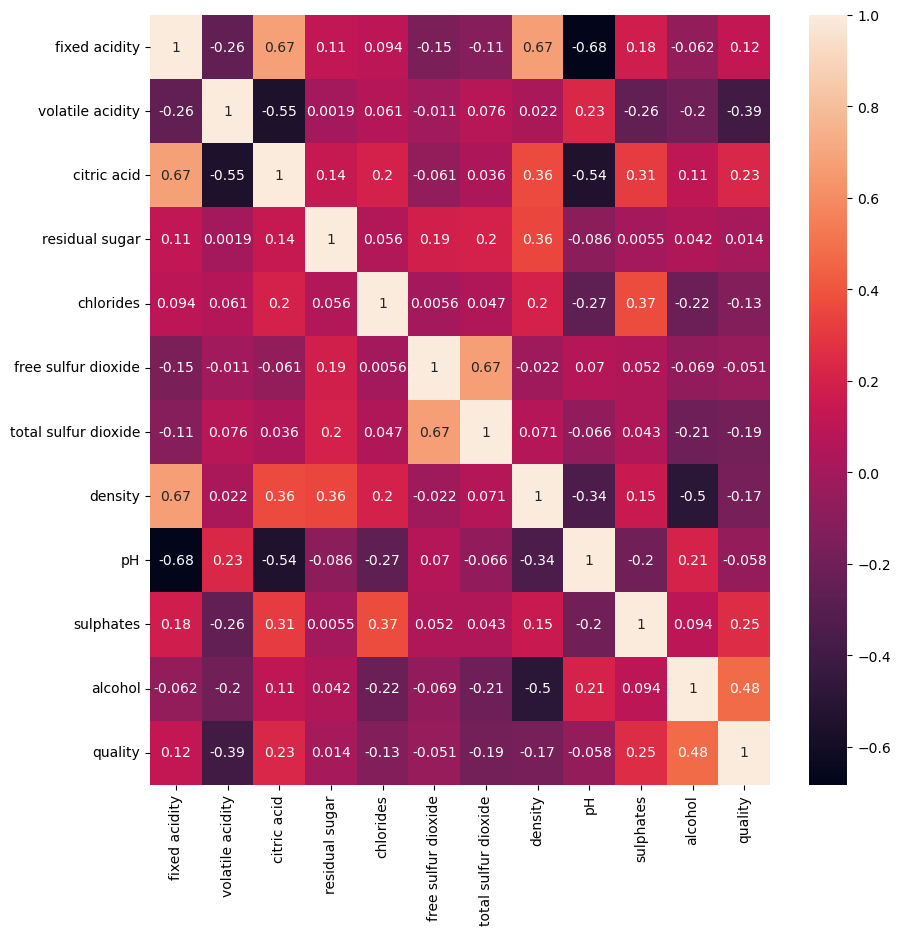

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [90]:
##################### All Together ###########################
# Step-1: import the packages

# Step-2: Read the data
df=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')

# Step-3: EDA: cleaned or preprocessed data
# step-4: Divide data into input(x) and output(y)

# input data
X=df.drop('quality',axis=1)
# output
y=df['quality']


# Step-5: divide the data into train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=1234)



# step-6: Develop the model
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)



# step-7: Model predictions
y_predictions=LR.predict(X_test)



# step-8: Evaluation
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import numpy as np
mse=mean_squared_error(y_test,y_predictions)
mae=mean_absolute_error(y_test,y_predictions)
R2_score=r2_score(y_test,y_predictions)
rmse=np.sqrt(mse)

In [91]:
# we developed the model
# you want to handover model to client
# we need to save the model in local, then we can share

# suppose your friend don't want to do all  10 steps from begining
# so you already developed the model
# share that model to me
# I will provide the test cases, So that will get the predictions

In [ ]:
# to save the model will use
# pickle
# joblib

# Google: tensorflow
# DL: tf.save()

In [96]:
# to save the model in local we will use package called ""pickle""
import pickle
pickle.dump(LR,open('linear_wine_model.pkl','wb'))

# or

# file_path=open('linear_wine_model.pkl','wb')
# model_name=LR
# pickle.dump(model_name,file_path)


In [ ]:
# Import the packages
# read the data
# Load the model
# pass the test case
# get the predictions

import numpy as np                                                                 
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



# read the data

df=pd.read_csv("C:\\Users\\SIDDESH R M\\Downloads\\winequality-red.csv",sep=';')

# Load the model
import pickle
saved_model=pickle.load(open('linear_wine_model.pkl','rb'))
saved_model

# pass the test case
saved_model.predict([[1,2,3,4,5,6,7,8,9,10,11]]) # this is called "End point prediction". when we will pass like ""predict(x_test)""  Batch prediction


# Dump : 'wb'  write bytes
# load : 'rb'  read bytes
# this files are in encode format thats why it is called "bytes"

$Step-10$:

In [97]:
# Original model LR
LR.coef_

array([ 1.30286848e-02, -1.08686529e+00, -1.06733841e-01,  1.56488869e-02,
       -1.69148075e+00,  4.82427344e-03, -3.64992541e-03, -1.83253991e+01,
       -4.41797201e-01,  8.50079329e-01,  2.77289269e-01])

In [98]:
LR.intercept_

np.float64(22.611604916395553)

In [99]:
X_train.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

In [ ]:
y=bo+b1*x1+b2*x2+....+bn*xn

y=22.611604916395553 + 1.30286848e-02*'fixed acidity' + -1.08686529e+00*'volatile acidity' +.......+ 2.77289269e-01*'alcohol'

In [ ]:
#Flask
#Django
#Gradio
#these 3 are used for API testing

#Function code is ready
#now you want to run that
#vscode terminal
#anaconda prompt


#for that normal function we need create an api: url
#that will achieved by Flask

#when you copy the URL and paste it in chrome, in vs code if i comes 200 , then it is sucessfull

#inside app.route('/') === nothing mentioned means by default "GET" request 
#inside app.route('/',methods=['Get'])


# 81 st class theory
#we already developed ML model : Linear regression

#you want to create an API for the test cases
#Flask with python

#dash board : application : reactjs html css js

#step-1: we saved the model : model.pkl
#step-2: will use this model as backend
#step-3: will Create Flask code
#step-4: pass the arguments requesr.args.get

